# Fluxnet EC vs. model comparison

Growing season May 1–Aug 31. Scatter: daytime 9–15h. Diurnal: all hours, hourly means ± std.

In [1]:
%matplotlib widget
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from dotenv import load_dotenv

load_dotenv('/Users/opa/pyAPES_main/.env')
sys.path.insert(0, '/Users/opa/pyAPES_main')
from pyAPES_utilities.timeseries_tools import diurnal_cycle

FI_HYY_EC_PATH = os.getenv('FI_HYY_EC_PATH')
US_PRR_EC_PATH = os.getenv('US_PRR_EC_PATH')

SITES = ['FI-Hyy', 'SE-Deg', 'DK-Sor', 'US-Prr']

NC_FILES = {
    'FI-Hyy': '/Users/opa/pyAPES_main/results/FiHy_2017_2018.nc',
    'SE-Deg': '/Users/opa/pyAPES_main/results/FiHy_2017_2018.nc',
    'DK-Sor': '/Users/opa/pyAPES_main/results/USPrr_2011_2013.nc',
    'US-Prr': '/Users/opa/pyAPES_main/results/USPrr_2011_2013.nc',
}

NC_YEARS = {'FI-Hyy': 2018, 'SE-Deg': 2017, 'DK-Sor': 2011, 'US-Prr': 2012}
EC_YEARS = {'FI-Hyy': 2018, 'SE-Deg': 2017, 'DK-Sor': 2011, 'US-Prr': 2012}
EC_TYPE  = {'FI-Hyy': 'fihyy', 'SE-Deg': 'fihyy', 'DK-Sor': 'usprr', 'US-Prr': 'usprr'}

# (label, nc_var, fihyy_col, usprr_col, unit)
VARIABLES = [
    ('GPP',   'canopy_GPP',         'GPP',   'GPP_NT_VUT_REF', 'umol m-2 s-1'),
    ('LE',    'canopy_LE',          'LE',    'LE_F_MDS',       'W m-2'),
    ('Rnet',  'canopy_Rnet',        'Rnet',  'NETRAD',         'W m-2'),
    ('SWnet', 'canopy_SWnet',       None,    'SWnet',          'W m-2'),
    ('H',     'canopy_SH',          'H',     'H_F_MDS',        'W m-2'),
    ('G',     'ffloor_ground_heat', 'Gflux', 'G_F_MDS',        'W m-2'),
]

In [2]:
FILL_VALUE = -9999.0


def load_model(site):
    ds = xr.open_dataset(NC_FILES[site])
    year = NC_YEARS[site]
    ds_yr = ds.sel(date=ds.date.dt.year == year)
    idx = pd.DatetimeIndex(ds_yr.date.values)
    df = pd.DataFrame(index=idx)
    for label, nc_var, _, _, _ in VARIABLES:
        if nc_var in ds_yr:
            v = ds_yr[nc_var].values
            if v.ndim == 2:
                v = v[:, 0]  # squeeze simulation dim
            df[label] = v
        else:
            df[label] = np.nan
    return df


def load_ec(site):
    year = EC_YEARS[site]
    ec_type = EC_TYPE[site]

    if ec_type == 'fihyy':
        df = pd.read_csv(FI_HYY_EC_PATH, sep=';', na_values=[FILL_VALUE, -9999])
        df = df[df['year'] == year].copy()
        df.index = pd.to_datetime({
            'year': df['year'], 'month': df['month'],
            'day': df['day'], 'hour': df['hour'], 'minute': df['minute']
        })
        col_map = {
            'GPP': 'GPP', 'LE': 'LE', 'Rnet': 'Rnet',
            'SWnet': None, 'H': 'H', 'G': 'Gflux'
        }
    else:
        df = pd.read_csv(US_PRR_EC_PATH, sep=';', na_values=[FILL_VALUE, -9999])
        df = df[df['year'] == year].copy()
        df.index = pd.to_datetime({
            'year': df['year'], 'month': df['month'],
            'day': df['day'], 'hour': df['hour'], 'minute': df['minute']
        })
        df['SWnet'] = df['SW_IN_F'] - df['SW_OUT']
        col_map = {
            'GPP': 'GPP_NT_VUT_REF', 'LE': 'LE_F_MDS', 'Rnet': 'NETRAD',
            'SWnet': 'SWnet', 'H': 'H_F_MDS', 'G': 'G_F_MDS'
        }

    result = pd.DataFrame(index=df.index)
    for label, _, _, _, _ in VARIABLES:
        key = col_map.get(label)
        if key and key in df.columns:
            result[label] = pd.to_numeric(df[key], errors='coerce').values
        else:
            result[label] = np.nan
    return result


def growing_season(df):
    return df[(df.index.month >= 5) & (df.index.month <= 8)]


def daytime(df):
    return df[(df.index.hour >= 9) & (df.index.hour <= 15)]

In [7]:
from sklearn.metrics import r2_score

In [3]:
def plot_scatter(ax, model_df, obs_df, label, unit):
    x = model_df[label].values
    y = obs_df[label].values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        return
    x, y = x[mask], y[mask]
    ax.scatter(x, y, s=1, alpha=0.3, color='steelblue', rasterized=True)
    vmin = min(x.min(), y.min())
    vmax = max(x.max(), y.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=0.8)
    r, _ = stats.pearsonr(x, y)
    rmse = np.sqrt(np.mean((x - y) ** 2))
    ax.text(0.05, 0.95, f'R²={r**2:.2f}\nRMSE={rmse:.1f}',
            transform=ax.transAxes, fontsize=6, va='top', linespacing=1.4)
    ax.tick_params(labelsize=6)
    ax.set_xlabel(f'Model ({unit})', fontsize=6)
    ax.set_ylabel(f'Obs ({unit})', fontsize=6)


def plot_diurnal(ax, model_df, obs_df, label, unit):
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m_dc = diurnal_cycle(model_df[[label]], ap='hour')
        o_dc = diurnal_cycle(obs_df[[label]], ap='hour')
    m = m_dc[label]
    o = o_dc[label]
    ax.plot(m['hour'], m['mean'], color='steelblue', lw=1.2, label='Model')
    ax.fill_between(m['hour'], m['mean'] - m['std'], m['mean'] + m['std'],
                    alpha=0.2, color='steelblue')
    ax.plot(o['hour'], o['mean'], color='firebrick', lw=1.2, label='Obs')
    ax.fill_between(o['hour'], o['mean'] - o['std'], o['mean'] + o['std'],
                    alpha=0.2, color='firebrick')
    ax.set_xlabel('Hour', fontsize=6)
    ax.set_ylabel(unit, fontsize=6)
    ax.set_xlim(0, 23)
    ax.tick_params(labelsize=6)

In [4]:
model_data = {site: load_model(site) for site in SITES}
obs_data   = {site: load_ec(site)   for site in SITES}
print('Data loaded.')
for site in SITES:
    print(f'  {site}: model={len(model_data[site])}, obs={len(obs_data[site])}')

Data loaded.
  FI-Hyy: model=17473, obs=17520
  SE-Deg: model=17520, obs=17520
  DK-Sor: model=17520, obs=17520
  US-Prr: model=17568, obs=17568


In [14]:
y_pred = model_data['FI-Hyy'].loc[model_data['FI-Hyy'].index.month.isin([4,5,6,7,8,9])].GPP

In [18]:
y_true = obs_data['FI-Hyy'].loc[obs_data['FI-Hyy'].index.month.isin([4,5,6,7,8,9])].GPP

In [22]:
r2_score(y_true, y_pred)

0.8832705758031386

********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycles *********
********** computing diurnal cycle

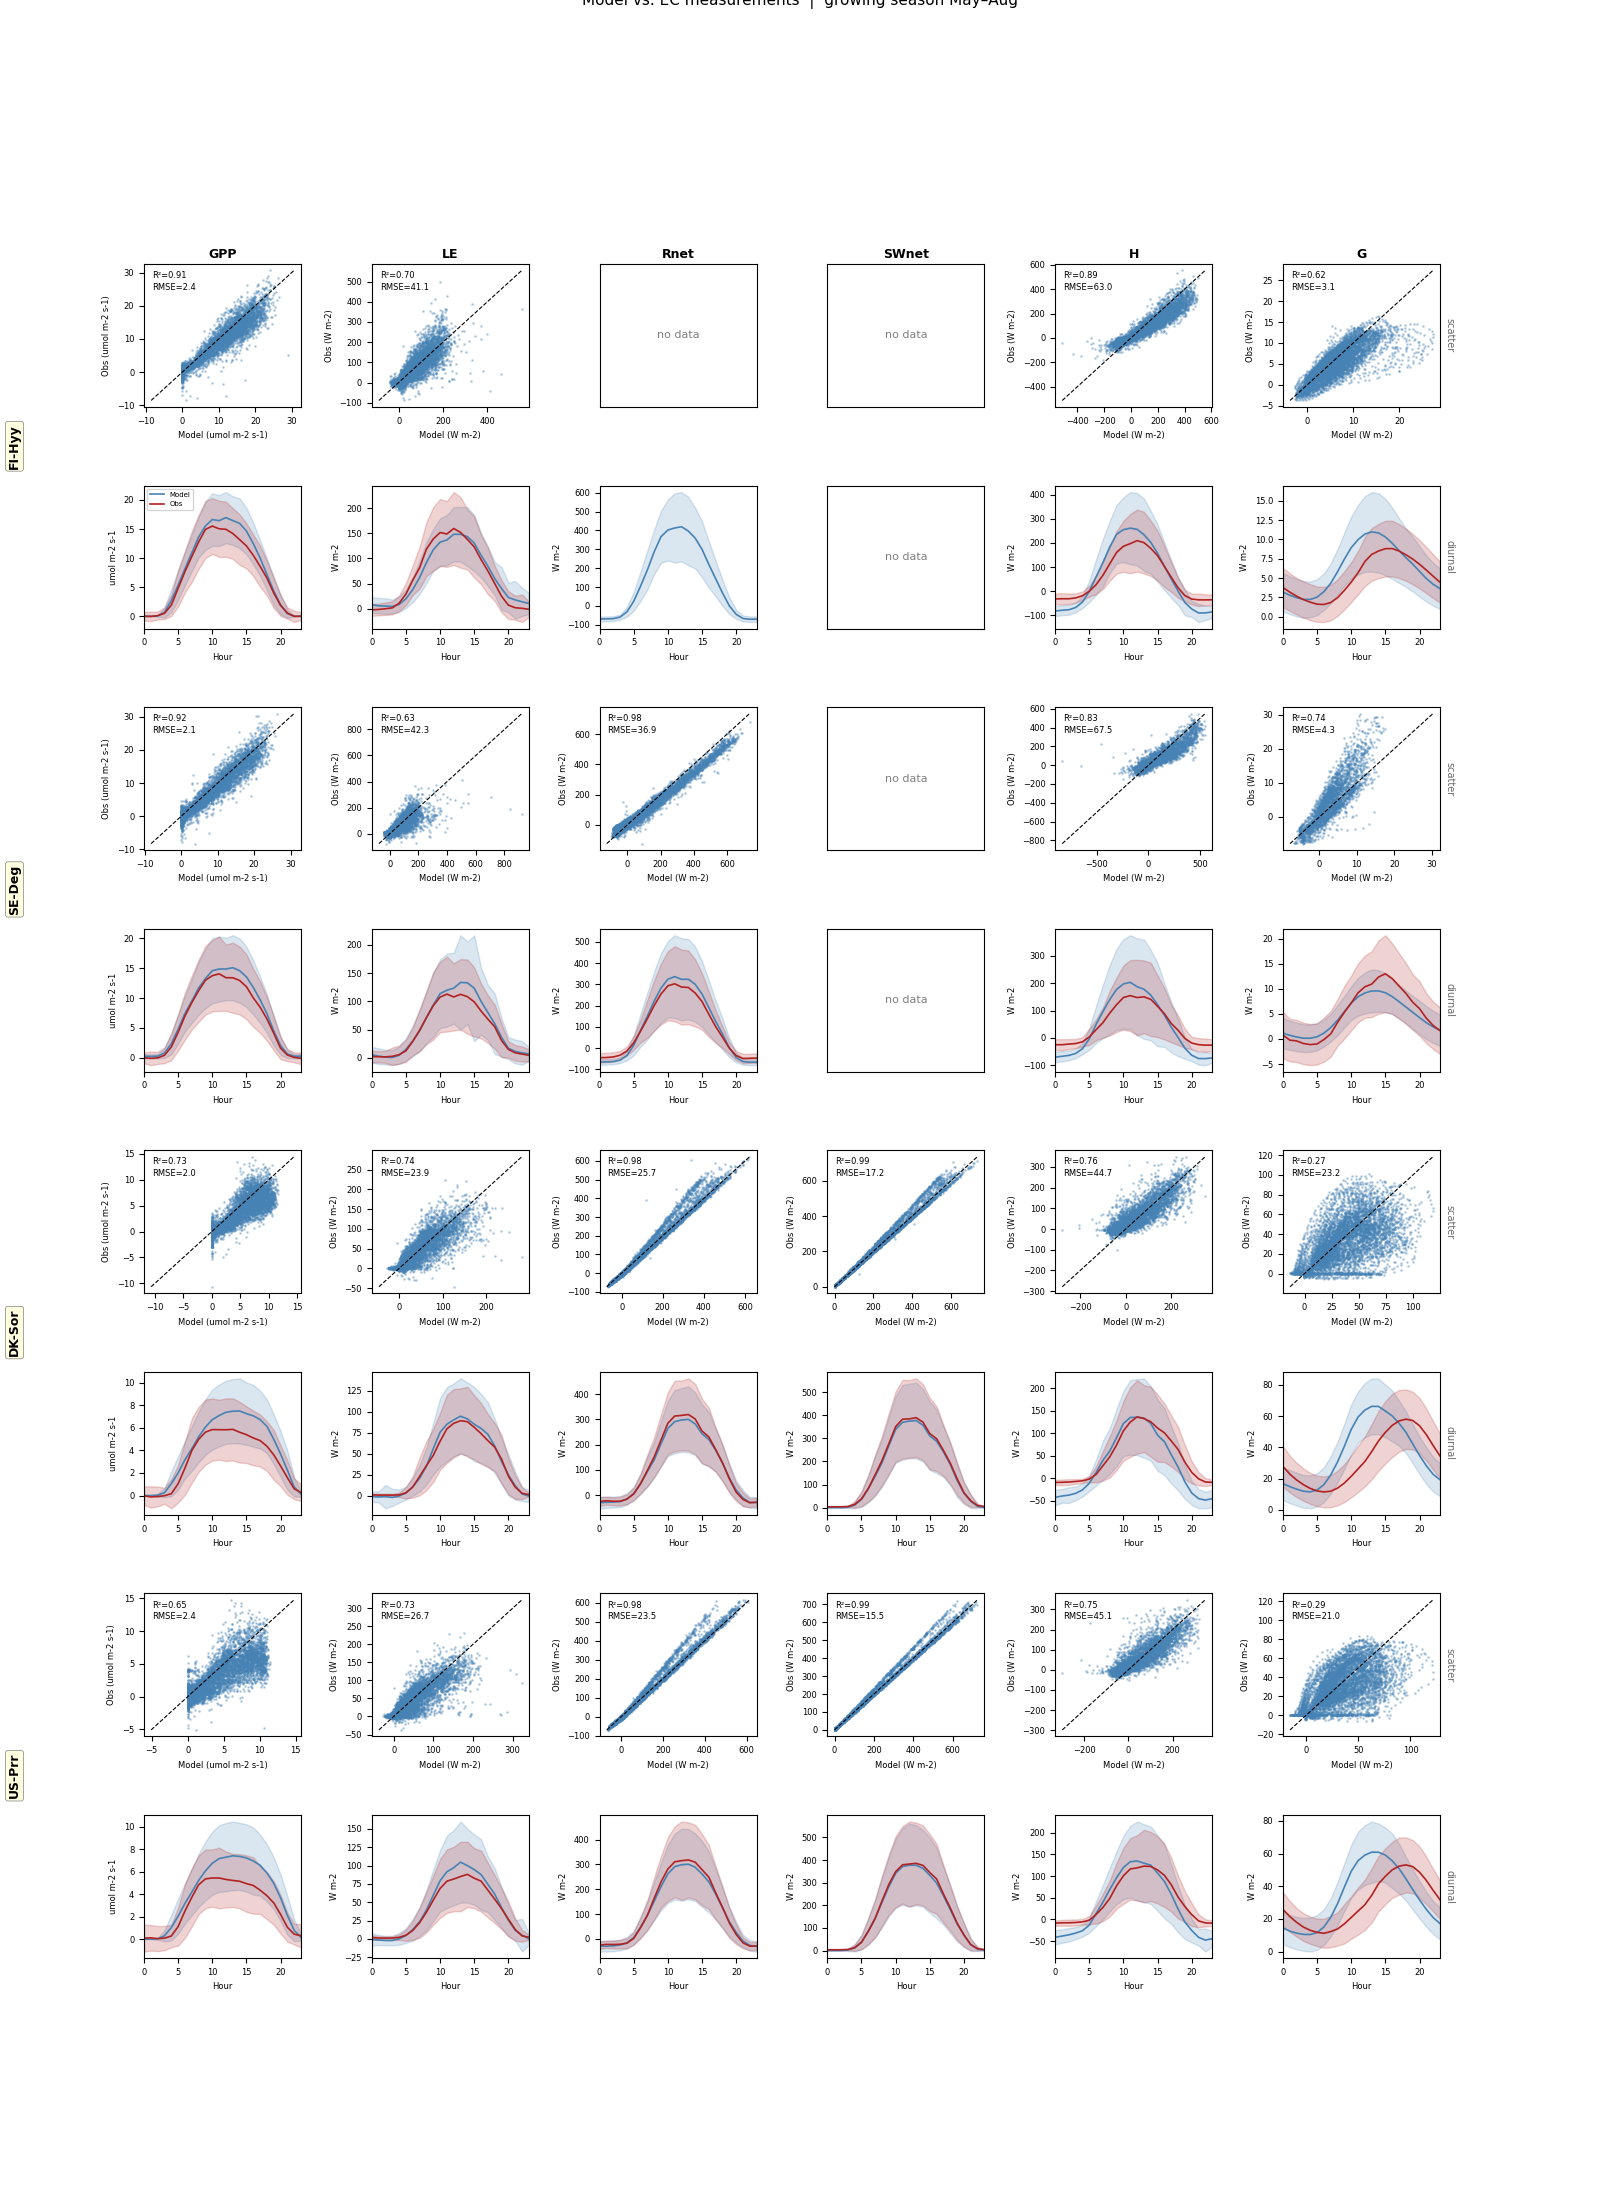

In [23]:
fig, axes = plt.subplots(8, 6, figsize=(16, 22))
fig.subplots_adjust(hspace=0.55, wspace=0.45, left=0.09)

# Column headers on first scatter row
for v_idx, (label, *_) in enumerate(VARIABLES):
    axes[0, v_idx].set_title(label, fontsize=9, fontweight='bold', pad=4)

for s_idx, site in enumerate(SITES):
    row_s = s_idx * 2      # scatter row
    row_d = s_idx * 2 + 1  # diurnal row

    model_gs    = growing_season(model_data[site])
    obs_gs      = growing_season(obs_data[site])
    #model_gs_dt = daytime(model_gs)
    #obs_gs_dt   = daytime(obs_gs)
    model_gs_dt = model_gs
    obs_gs_dt  = obs_gs

    for v_idx, (label, nc_var, fihyy_col, usprr_col, unit) in enumerate(VARIABLES):
        ax_s = axes[row_s, v_idx]
        ax_d = axes[row_d, v_idx]

        no_data = (label == 'SWnet' and EC_TYPE[site] == 'fihyy')

        if no_data:
            for ax in [ax_s, ax_d]:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                        ha='center', va='center', fontsize=8, color='gray')
                ax.set_xticks([])
                ax.set_yticks([])
        else:
            plot_scatter(ax_s, model_gs_dt, obs_gs_dt, label, unit)
            plot_diurnal(ax_d, model_gs, obs_gs, label, unit)
            if s_idx == 0 and v_idx == 0:
                ax_d.legend(fontsize=5, loc='upper left', framealpha=0.8)

    # Site label centered on the left between the two rows
    pos_s = axes[row_s, 0].get_position()
    pos_d = axes[row_d, 0].get_position()
    mid_y = (pos_s.y1 + pos_d.y0) / 2
    fig.text(0.005, mid_y, site, va='center', ha='left',
             fontsize=9, fontweight='bold', rotation=90,
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', ec='gray', lw=0.5))

    # Row type labels on the far right
    axes[row_s, -1].annotate('scatter', xy=(1.03, 0.5), xycoords='axes fraction',
                              fontsize=7, va='center', rotation=-90, color='dimgray')
    axes[row_d, -1].annotate('diurnal', xy=(1.03, 0.5), xycoords='axes fraction',
                              fontsize=7, va='center', rotation=-90, color='dimgray')

fig.suptitle('Model vs. EC measurements  |  growing season May–Aug',
             fontsize=11, y=1.003)
plt.show()